In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#import gym
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import random
import pdb
import plotly.express as px
import plotly.graph_objects as go
import pickle
import scipy.io
from matplotlib.font_manager import FontProperties
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
import matplotlib.animation as animation
import glob
#from natsort import natsorted
from PIL import Image

def create_gif(pth, time_ind):
    #files = glob.glob(r"./imgs/*.png")
    files = glob.glob(os.path.join(pth,'*.png'))
    files = natsorted(files)
    image_array = []
    
    def update(i):
        im.set_array(image_array[i])
        return im, 
    
    for my_file in files:

        image = Image.open(my_file)
        image_array.append(image)
    
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=100, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    #animation_fig.save("./imgs/animated_{}.gif".format(time_ind))
    animation_fig.save(os.path.join(pth,'animated_{}.gif').format(time_ind))
    pass

### Adding gamma_0 value for SINR computation ####

$\gamma = \frac{|h|_s^2P_t}{|h|_i^2P_t + N_0B}$

Assuming power transmitted power is same from all BSs then we have 

$\gamma = \frac{|h|_s^2}{|h|_i^2 + \frac{1}{\gamma_0}}$


where $\gamma_0 = P_t/N_0B$, you can assume P_t = 10 dBm, and the below calculations for $N_0$

In [2]:
## transmit power ###
Pt_dBm = 10  # Transmit power in dBm

#### Noise power ####
k = 1.38e-23  # Boltzmann's constant
T = 290       # Temperature in Kelvin
B = 10e6       # Bandwidth in Hz

# Calculate noise spectral density in Watts/Hz
Noise_spectral_density = k * T

# Convert noise spectral density to dBm/Hz
# Convert to Watts first then to dBm (1 mW = 0.001 W)
Noise_spectral_density_W = Noise_spectral_density * 1000  # Convert to mW
Noise_spectral_density_dBm = 10 * np.log10(Noise_spectral_density_W)
print('Noise_spectral_density_dBm', Noise_spectral_density_dBm)

# Calculate total noise power in Watts then convert to dBm
N_thermal = Noise_spectral_density * B  # Total noise power in Watts
N_thermal_dBm = 10 * np.log10(N_thermal * 1000)  # Convert noise power to dBm
print('thermal_noise_power(dBm)', N_thermal_dBm)

##### gamma_0 in dB ############
gamma_0_dB = Pt_dBm - N_thermal_dBm  # Calculate SNR in dB
#print('gamma_0 (dB)', gamma_0_dB)

##### gamma_0 ######
gamma_0 = np.power(10, gamma_0_dB/10)
print('1/gamma_0', 1/gamma_0)

Noise_spectral_density_dBm -173.97722915699805
thermal_noise_power(dBm) -103.97722915699808
1/gamma_0 4.001999999999999e-12


### 
CDF of SINR computed for F($\gamma$), for different channel realizations,
below is when the the device is at a mean distance of 1m from the serving BS with a standard deviation of 0.1 m, and mean distance from the interfering BS at 4 meters with std of 0.1m 

In [3]:
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

In [4]:
############## Creating distances intra and inter ########
M = 8   # number of sub-networks
Ts = 10000  # number of time slots
J = 3   # number of devices per sub-network
f_c = 1.3   # GHz
N = 20  # number of sub-channels

TxRxds = np.zeros((Ts, M, M*J))
d_intra = np.abs(np.random.normal(0.5, 0.1, M*J))
d_intra = np.reshape(d_intra, (M, J))

In [5]:
'''
for ts in range(Ts):
    d_inter_intra_arr = np.zeros((M, M*J))
    for cnt, m in enumerate(range(M)):
        d_inter = []
        #total_range = list(range(1, 21))
        for _ in range(M-1):
            d_mean = random.randint(2,20)
            #d_mean = random.choice(total_range)
            #total_range = [t for t in total_range if t!=d_mean]
            
            #d_mean = np.random.uniform(1,20)
            ds = np.abs(np.random.normal(d_mean, 0.1, J))
            d_inter.extend(ds)
        d_inter = np.array(d_inter)
        d_inter_intra = np.insert(d_inter, cnt*M, d_intra[m,:])
        #print(d_inter_intra)
        d_inter_intra_arr[m] = d_inter_intra
    TxRxds[ts] = d_inter_intra_arr
''';

In [6]:
def generate_random_point(grid_size):
    return np.random.uniform(0, grid_size, 2)

def generate_random_velocity():
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11  # 40 km/h in m/s
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def is_within_grid(point, grid_size):
    return all(0 <= coord <= grid_size for coord in point)

def handle_boundary_collisions(point, grid_size):
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11
    if point[0] <= 0 or point[0] >= grid_size:
        angle = np.pi - angle if point[0] <= 0 else -angle
    if point[1] <= 0 or point[1] >= grid_size:
        angle = -np.pi / 2 - angle if point[1] <= 0 else np.pi / 2 - angle
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def handle_ap_collisions(points, velocities, min_distance):
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if np.linalg.norm(points[i] - points[j]) < min_distance:
                # Adjust direction randomly for both APs
                velocities[i] = generate_random_velocity()
                velocities[j] = generate_random_velocity()
    return velocities

def update_positions(points, velocities, tau, grid_size, min_distance):
    new_points = points + velocities * tau
    for i, point in enumerate(new_points):
        if not is_within_grid(point, grid_size):
            velocities[i] = handle_boundary_collisions(point, grid_size)
        new_points[i] = points[i] + velocities[i] * tau  # Recalculate with new velocity
    velocities = handle_ap_collisions(new_points, velocities, min_distance)
    return new_points, velocities

# Initialize parameters
grid_size = 20
num_points = M
min_distance = 2
tau = 0.01  # time interval in seconds

# Initialize points and velocities
points = np.array([generate_random_point(grid_size) for _ in range(num_points)])
velocities = np.array([generate_random_velocity() for _ in range(num_points)])
init_cents = points
# Simulation loop for 20 time steps
pth = r'C:\Users\sriniva3\OneDrive - Aalto University\Simulations\RL framework URLLC\RL framework_V2.0_DDPG\imgs'
#Ts = 1000
sub_net_cents = np.zeros((Ts+1, num_points, 2))
sub_net_cents[0] = init_cents
for step in tqdm(range(Ts-1)):
    points, velocities = update_positions(points, velocities, tau, grid_size, min_distance)
    sub_net_cents[step+1] = points
    '''
    # Plotting for visualization
    plt.figure(figsize=(3, 3))
    plt.scatter(points[:, 0], points[:, 1], c='red', label=f'Time Step {step+1}')
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.grid(True)
    plt.title(f'Access Points at Step {step+1}')
    plt.xlabel('Meters')
    plt.ylabel('Meters')
    #plt.legend()
    plt.savefig(os.path.join(pth, '{}.png'.format(step)))
    plt.close()
    #plt.show()
    ''';
#create_gif(pth, step)

100%|████████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:02<00:00, 3434.40it/s]


In [7]:
d_relative_locs = {}
for i in range(M):
    d_angle = np.random.uniform(0,2*np.pi,J) 
    d_r = np.random.uniform(0, 1, J)
    d_relative_locs[i] = np.vstack([d_r*np.cos(d_angle), d_r*np.sin(d_angle)])

In [8]:
def return_euclid_dist(device_x_coord, device_y_coord, AP_x_coord, AP_y_coord):
    device_coords = np.array([device_x_coord, device_y_coord])
    AP_coords = np.array([AP_x_coord, AP_y_coord])
    return np.linalg.norm(device_coords - AP_coords)

x_coords_ts, y_coords_ts = {}, {}
for ts in range(Ts):
    coords = sub_net_cents[ts]
    point_xs, point_ys = [], []
    for k in d_relative_locs.keys():
        point_x = d_relative_locs[k][0] + coords[k][0]
        point_y = d_relative_locs[k][1] + coords[k][1]
        #print(point_x, point_y)
        point_xs.append(point_x)
        point_ys.append(point_y)
    #break    
    x_coords_ts[ts] = point_xs
    y_coords_ts[ts] = point_ys

In [9]:
TxRxds = np.zeros((Ts, M, M*J))
for ts in range(Ts):
    device_x_coords, device_y_coords = np.array(x_coords_ts[ts]), np.array(y_coords_ts[ts])
    device_x_coords, device_y_coords = device_x_coords.flatten(), device_y_coords.flatten()
    AP_x_coords, AP_y_coords = sub_net_cents[ts][:,0], sub_net_cents[ts][:,1]
    
    #for dx in device_x_coords 
    dists = np.zeros((M,M*J))
    for i in range(AP_x_coords.shape[0]):
        dist = []
        for j in range(len(device_x_coords.flatten())):
            #dist = []
            #print(i,j)
            dist.append(return_euclid_dist(device_x_coords[j], device_y_coords[j], AP_x_coords[i], AP_y_coords[i]))
            #print(dist)
        dists[i] = np.array(dist)
    TxRxds[ts] = dists
    #break

#dist = return_euclid_dist(x_coords_ts[0], y_coords_ts[0], AP_x_coord, AP_y_coord)

### Using Jakes model 

In [11]:
def return_jakes_coeffcients(fd_max, TimeVaris, n_links=5, plot=True):
    ff_gains, TimeSequences = [], []
    rays = 100
    for i in tqdm(range(n_links)):
        frequs = np.sort(
            np.array([np.round(fd_max * np.cos(2 * np.pi * np.random.uniform(0, 1)))
                      for _ in range(rays)])
        )
        phases = np.array([np.exp(1j * 2 * np.pi * np.random.uniform(0, 1))
                           for _ in range(rays)])

        TimeSequence = []
        for t in TimeVaris:
            tab = np.exp(1j * 2 * np.pi * frequs * t)
            tabrot = tab * phases
            fun = np.sum(tabrot)
            TimeSequence.append(fun)

        TimeSequence = np.array(TimeSequence)
        PowerSequence1 = np.abs(TimeSequence) ** 2
        ff_gains.append(PowerSequence1)
        TimeSequences.append(TimeSequence)

    ff_gains = np.array(ff_gains) / rays
    TimeSequences = np.array(TimeSequences)

    if plot:
        plt.figure(figsize=(5, 3))
        plt.plot(TimeVaris[:200], 10 * np.log10(np.maximum(ff_gains[0][:200], 1e-30)))
        plt.grid()
        plt.xlabel('Time')
        plt.ylabel('Jakes power gain (dB)')
        plt.show()

    return ff_gains, TimeSequences


v = 40  # kmph
v_ms = v * 5 / 18
c = 3e8
tau = 0.01

fd_max = v_ms * f_c * 1e9 / c

# safer than np.arange for exact Ts points
TimeVaris = np.linspace(0, 5, Ts, endpoint=False)

# one Jakes sequence for every interfering link and sub-channel
n_links = M * (M - 1) * J * N

ff_gains, TimeSequences = return_jakes_coeffcients(fd_max, TimeVaris, n_links=n_links, plot=False)

100%|██████████████████████████████████████████████████████████████████████████████████| 3360/3360 [12:30<00:00,  4.48it/s]


In [12]:
def build_all_fast_fading_gains(FadingGains_desired, ff_gains_ts, M, J, N):
    """
    FadingGains_desired: shape (M, J, N)
    ff_gains_ts: shape (M*(M-1)*J*N,) at one time slot

    Returns:
        all_fast_fading_gains: shape (M, M*J, N)

    For each AP m, the desired-link gains are placed into columns m*J:(m+1)*J,
    and the interfering gains are placed into all other device columns in the
    same global order as TxRxds.
    """
    jakes_coeffs = np.reshape(ff_gains_ts, (M, (M - 1) * J, N))
    all_fast_fading_gains = np.zeros((M, M * J, N))

    for m in range(M):
        # place desired links into their true global columns
        all_fast_fading_gains[m, m*J:(m+1)*J, :] = FadingGains_desired[m]

        # place interfering links into the remaining subnet blocks
        ptr = 0
        for k in range(M):
            if k == m:
                continue
            all_fast_fading_gains[m, k*J:(k+1)*J, :] = jakes_coeffs[m, ptr:ptr+J, :]
            ptr += J

    return all_fast_fading_gains

In [13]:
############ Rician desired links + Jakes interfering links across N subchannels ########

K = 4  # Rician K-factor
eps = 1e-30

# Rician fading for desired links only
LOS_scale = np.sqrt(K / (K + 1))
NLOS_scale = np.sqrt(1 / (K + 1))

random_phase = np.exp(1j * 2 * np.pi * np.random.rand(M, J, N))
LOS_component = LOS_scale * np.ones((M, J, N)) * random_phase
NLOS_component = NLOS_scale * (
    np.random.normal(0, 1 / np.sqrt(2), (M, J, N)) +
    1j * np.random.normal(0, 1 / np.sqrt(2), (M, J, N))
)

FastFadingChannels_desired = LOS_component + NLOS_component
FadingGains_desired = np.abs(FastFadingChannels_desired) ** 2  # (M, J, N)

# store full tensors
all_SINRsdB = np.zeros((Ts, M, J, N))
all_MeansPerSubNW = np.zeros((Ts, M))
all_DiffsFromMean = np.zeros((Ts, M, J, N))

alltime_WantedSigPerDev = []
alltime_InterfPowsPerDev = []
alltime_SINRsdB_combined = []

for ts in tqdm(range(Ts)):

    # Build full fading tensor aligned with TxRxds indexing
    all_fast_fading_gains = build_all_fast_fading_gains(
        FadingGains_desired=FadingGains_desired,
        ff_gains_ts=ff_gains[:, ts],
        M=M, J=J, N=N
    )  # shape: (M, M*J, N)

    # safe distances
    TxRxd_safe = np.maximum(TxRxds[ts], 1e-3)

    # path loss
    PL_los = 31.84 + 21.5 * np.log10(TxRxd_safe) + 19 * np.log10(f_c)
    PL = 33.0 + 25.5 * np.log10(TxRxd_safe) + 20 * np.log10(f_c)
    PL_nlos = np.maximum(PL_los, PL)

    PathGains = np.power(10, -PL_nlos / 10)              # (M, M*J)
    PathGains = np.repeat(PathGains[:, :, np.newaxis], N, axis=2)  # (M, M*J, N)

    # total channel power gains
    PathGainsTot = PathGains * all_fast_fading_gains     # (M, M*J, N)

    # desired signal powers
    WantedSigPerDev = np.zeros((M, J, N))
    for m in range(M):
        WantedSigPerDev[m] = PathGainsTot[m, m*J:(m+1)*J, :]

    # interference powers
    InterfPowsPerDev = np.zeros((M, J, N))
    for m in range(M):
        Interferers = [i for i in range(M) if i != m]
        Devs = np.arange(m*J, (m+1)*J)

        # shape after indexing: ((M-1), J, N)
        InterfPowGains = PathGainsTot[np.ix_(Interferers, Devs, np.arange(N))]
        InterfPowsPerDev[m] = np.sum(InterfPowGains, axis=0)

    # SINR
    SINRs = WantedSigPerDev / (InterfPowsPerDev + 1 / gamma_0)
    SINRsdB = 10 * np.log10(np.maximum(SINRs, eps))

    # mean SINR per subnet, averaged across devices and sub-channels
    MeansPerSubNW = np.mean(SINRsdB, axis=(1, 2))   # shape: (M,)

    # deviations from subnet mean
    DiffsFromMean = SINRsdB - MeansPerSubNW[:, np.newaxis, np.newaxis]

    # optional combined SINR across N subchannels
    SINRs_combined = np.min(SINRs, axis=2)  # shape (M, J)
    SINRsdB_combined = 10 * np.log10(np.maximum(SINRs_combined, eps))

    # store
    all_SINRsdB[ts] = SINRsdB
    all_MeansPerSubNW[ts] = MeansPerSubNW
    all_DiffsFromMean[ts] = DiffsFromMean

    alltime_WantedSigPerDev.append(WantedSigPerDev)
    alltime_InterfPowsPerDev.append(InterfPowsPerDev)
    alltime_SINRsdB_combined.append(SINRsdB_combined)

alltime_WantedSigPerDev = np.array(alltime_WantedSigPerDev)        # (Ts, M, J, N)
alltime_InterfPowsPerDev = np.array(alltime_InterfPowsPerDev)      # (Ts, M, J, N)
alltime_SINRsdB_combined = np.array(alltime_SINRsdB_combined)      # (Ts, M, J)

all_Int_pows_dBm = 10 * np.log10(np.maximum(alltime_InterfPowsPerDev, eps))

print("all_SINRsdB shape:", all_SINRsdB.shape)
print("all_MeansPerSubNW shape:", all_MeansPerSubNW.shape)
print("all_DiffsFromMean shape:", all_DiffsFromMean.shape)
print("all_Int_pows_dBm shape:", all_Int_pows_dBm.shape)
print("alltime_SINRsdB_combined shape:", alltime_SINRsdB_combined.shape)

100%|██████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:08<00:00, 1229.39it/s]


all_SINRsdB shape: (10000, 8, 3, 20)
all_MeansPerSubNW shape: (10000, 8)
all_DiffsFromMean shape: (10000, 8, 3, 20)
all_Int_pows_dBm shape: (10000, 8, 3, 20)
alltime_SINRsdB_combined shape: (10000, 8, 3)


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


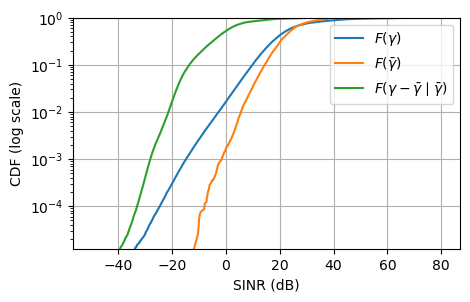

In [14]:
a1, cdf1 = return_cdf(all_SINRsdB.flatten())
a2, cdf2 = return_cdf(all_MeansPerSubNW.flatten())
a3, cdf3 = return_cdf(all_DiffsFromMean.flatten())

plt.figure(figsize=[5, 3])
plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label=r'$F(\gamma)$')
plt.semilogy(a2, cdf2, label=r'$F(\bar{\gamma})$')
plt.semilogy(a3, cdf3, label=r'$F(\gamma-\bar{\gamma}\mid \bar{\gamma})$')
plt.grid()
plt.xlabel('SINR (dB)')
plt.ylabel('CDF (log scale)')
plt.legend()
plt.show()

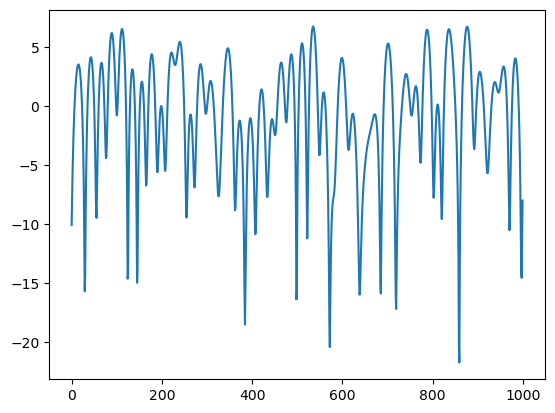

In [20]:
plt.plot(10*np.log10(ff_gains[2].flatten()[0:1000]))
plt.show()